In [8]:
#pip install tensorflow


In [9]:
#pip install pandas numpy matplotlib scikit-learn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score


In [11]:
# 1. Load dữ liệu
df = pd.read_csv("../../data/processed/training_data_final (only Gold).csv", parse_dates=["Datetime"], index_col="Datetime")

# Chọn cột GOLD để dự đoán
data = df[["Gold"]]

In [12]:
# 2. Tiền xử lí dữ liệu
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [13]:
# 3. Tạo tập dữ liệu huấn luyện và kiểm tra
X, y = [], []
window = 60  # 60 phút trước

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i, 0])  
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


In [14]:
# 4.Reshape dữ liệu cho LSTM (3D)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
# Chia train/test theo thời gian
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [15]:
# 5.Xây dựng mô hình LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# 6. Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 102s 45ms/step - loss: 0.0012 - val_loss: 5.0541e-07
Epoch 2/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 183s 64ms/step - loss: 8.5423e-05 - val_loss: 7.9582e-07
Epoch 3/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 141s 64ms/step - loss: 7.3097e-05 - val_loss: 1.2008e-05
Epoch 4/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 121s 54ms/step - loss: 5.5055e-05 - val_loss: 2.0421e-08
Epoch 5/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 137s 51ms/step - loss: 4.1395e-05 - val_loss: 2.5792e-07
Epoch 6/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 138s 50ms/step - loss: 3.4006e-05 - val_loss: 6.5832e-09
Epoch 7/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 90s 42ms/step - loss: 2.9993e-05 - val_loss: 3.4140e-09
Epoch 8/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 141s 42ms/step - loss: 2.9820e-05 - val_loss: 1.2749e-07
Epoch 9/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 142s 42ms/step - loss: 2.1768e-05 - val_loss: 8.0868e-08
Epoch 10/20
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 88s 41ms/step - loss: 2.7218e-05 - val_loss: 9.8529e-08
Epoch 11/20
213

In [17]:
# 7. Dự đoán
y_pred_scaled = model.predict(X_test)

# Chuyển từ [0,1] về giá thật
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


594/594 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step


In [18]:
# 8. Đánh giá mô hình
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("RMSE:", rmse)
print("R² score:", r2)


RMSE: 0.003663457220495212
R² score: 0.9987118099085158


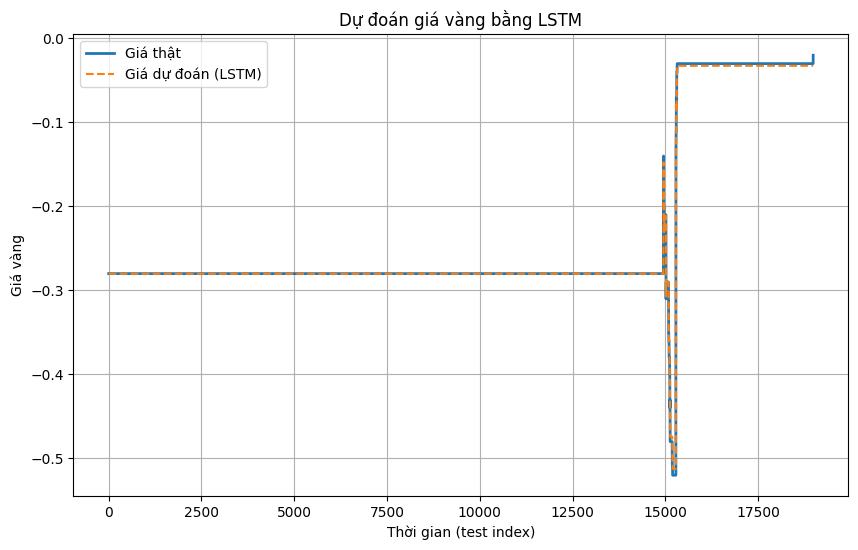

In [19]:
# 9. Vẽ biểu đồ dự đoán
plt.figure(figsize=(10,6))
plt.plot(y_test_real, label="Giá thật", linewidth=2)
plt.plot(y_pred, label="Giá dự đoán (LSTM)", linestyle='--')
plt.title("Dự đoán giá vàng bằng LSTM")
plt.xlabel("Thời gian (test index)")
plt.ylabel("Giá vàng")
plt.legend()
plt.grid(True)
plt.show()
